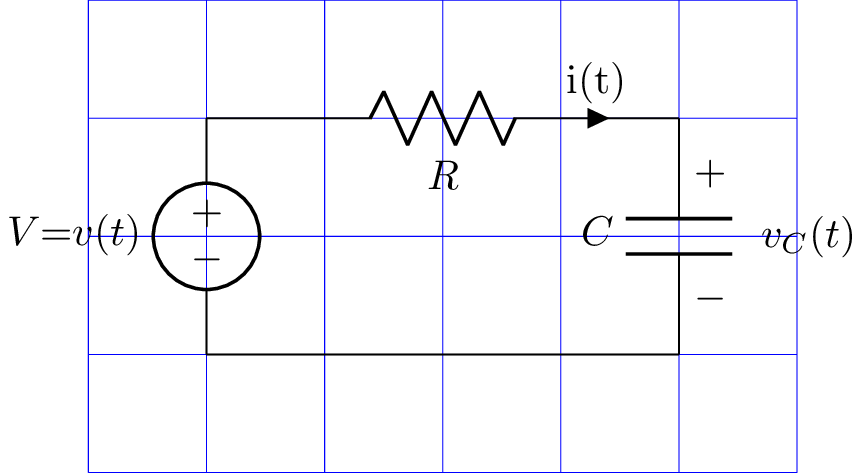

In [ ]:
from lcapy import *

cct = Circuit("""
V 1 0 {v(t)}; down
R 1 2; right=2, i=i(t)
C 2 0_2; down, v=v_C(t)
W 0 0_2; right
; draw_nodes=connections, label_ids=true, label_nodes=none, help_lines=1""")

cct.draw()

In [ ]:
from lcapy import *

cct = Circuit("""
V 1 0 {v(t)}; down
R1 1 2; right, i=i(t)
TF  3 0_3 2 0_2 k;right down
W 0 0_2; right
W 3 4; right
C1 4 0_4; down
W 0_3 0_4; right
R2 4 5; right
L 5 6; right
C2 6 0_6; down
W 0_4 0_6; right
W 6 7; right  
W 0_6 0_7; right
TF2 8 0_8 7 0_7 k2; right down 
W 8 9; right
Z 9 0_9; down
W 0_8 0_9; right
; draw_nodes=connections, label_ids=true, label_nodes=none, help_lines=0""")

cct.draw("tmp.tex")

In [50]:
cct.annotate_node_voltages((1, 2, 3)).draw()

/Users/bcornelusse/Documents/GitHub/ELEC0053-circuits-electriques/.venv/lib/python3.13/site-packages/lcapy/matrix.py:297: UserWarning: 
This may take a while...  A symbolic matrix inversion is O(12^3) for a matrix
of size 12x12
  warn("""
/Users/bcornelusse/Documents/GitHub/ELEC0053-circuits-electriques/.venv/lib/python3.13/site-packages/lcapy/netlist.py:365: SyntaxWarning: invalid escape sequence '\,'
  """Annotate specified list of component names `cpts` with current (or
/Users/bcornelusse/Documents/GitHub/ELEC0053-circuits-electriques/.venv/lib/python3.13/site-packages/lcapy/netlist.py:417: SyntaxWarning: invalid escape sequence '\,'
  """Annotate specified list of component names `cpts` with voltage.
/Users/bcornelusse/Documents/GitHub/ELEC0053-circuits-electriques/.venv/lib/python3.13/site-packages/lcapy/netlist.py:467: SyntaxWarning: invalid escape sequence '\,'
  """Create a new netlist with the node voltages annotated.  This is


KeyboardInterrupt: 

In [2]:
import numpy as np

P = 10e6
Q = 2e6
V_r = 15e3
k_r = 15
k_s = 11
w = 2*np.pi*50
C = 3.4e-6/(2*np.pi*60) * 100 / 2 # F
L= 66e-3  # H
R = 3 
R_s = 2

I_r = complex(P, Q).conjugate()/V_r
print(f"I_r = {I_r:.2f} A")
I_1 = I_r / k_r
V_1 = complex(V_r,0) * k_r
print(f"I_1 = {I_1:.2f} A")
print(f"V_1 = {V_1:.2f} V")
I_Cd = complex(0, w*C) * V_1
I_2 = I_1 + I_Cd
V_2 = V_1 + I_2 * (complex(R, w*L))
print(f"I_2 = {I_2:.2f} A")
print(f"V_2 = {V_2:.2f} V")
I_C_g = complex(0, w*C) * V_2
I_3 = I_2 + I_C_g
print(f"I_3 = {I_3:.2f} A")
V_4 = V_2 / k_s
I_4 = I_3 * k_s
print(f"V_4 = {V_4:.2f} V")
print(f"I_4 = {I_4:.2f} A")
V_s = V_4 + I_4 * (complex(R_s,0))
print(f"V_s = {V_s:.2f} V")
S_s = V_s * I_4.conjugate()
print(f"S_s = {S_s*1e-6:.2f} MW")

Z = V_r/I_r
print(f"Z = {Z:.2f} Ohm")

I_r = 666.67-133.33j A
I_1 = 44.44-8.89j A
V_1 = 225000.00+0.00j V
I_2 = 44.44+22.99j A
V_2 = 224656.73+990.49j V
I_3 = 44.30+54.81j A
V_4 = 20423.34+90.04j V
I_4 = 487.35+602.94j A
V_s = 21398.03+1295.92j V
S_s = 11.21-12.27j MW
Z = 21.63+4.33j Ohm


In [36]:
print(C)

4.509390054270368e-07


(21.634615384615383+4.326923076923077j)

In [1]:
import numpy as np

P = 30e6
Q = 8e6
approx_V_r = complex(15e3, 0)
Z_r = approx_V_r**2/complex(P,Q).conjugate()


k_r = 15
k_s = 11
w = 2*np.pi*50
C = 3.4e-6/(2*np.pi*60) * 100 / 2 # F
L= 66e-3  # H
R = 3 
R_s = 0.01
V_s = complex(21e3, 0)

G = np.zeros((4,4), dtype=complex)
G[0,0] = 1/(k_s*R_s)
G[0,1] = 1/(complex(R, w*L)) + complex(0, w*C)
G[0,2] = -1/(complex(R, w*L))
G[1,0] = k_s
G[1,1] = -1
G[2,1] = -1/(complex(R, w*L))
G[2,2] = 1/(complex(R, w*L)) + complex(0, w*C)
G[2,3] = 1/ (k_r*Z_r)
G[3,2] = -1/k_r
G[3,3] = 1

i_sN = np.zeros((4,1), dtype=complex)
i_sN[0] = V_s/(k_s*R_s)

v = np.linalg.solve(G, i_sN)
print("V_1 = ", v[0,0])
print("V_2 = ", v[1,0])
print("V_3 = ", v[2,0])
print("V_r = ", v[3,0])

import tabulate
print(tabulate.tabulate(G))

print(f"Z_r = {Z_r:.2f} Ohm")
V_r = v[3,0]
I_R = V_r / Z_r
print(f"V_R = {V_r*1e-3:.6f} kV")
print(f"I_R = {I_R*1e-3:.6f} kA")
S = V_r * I_R.conjugate()
print(f"S = {S*1e-6:.2f} MVA")

V_1 =  (20984.991641899887-2.9972711354852297j)
V_2 =  (230834.90806089877-32.96998249033753j)
V_3 =  (230312.52356465103-2845.5209121215507j)
V_r =  (15354.168237643402-189.7013941414367j)
--------  -----------  -----------  ----------
 9.09091   0.00683496  -0.00683496  0
11        -1            0           0
 0        -0.00683496   0.00683496  0.00888889
 0         0           -0.0666667   1
--------  -----------  -----------  ----------
Z_r = 7.00+1.87j Ohm
V_R = 15.354168-0.189701j kV
I_R = 2.040477-0.571220j kA
S = 31.44+8.38j MVA


/Users/bcornelusse/Documents/GitHub/ELEC0053-circuits-electriques/.venv/lib/python3.13/site-packages/tabulate/__init__.py:827: ComplexWarning: Casting complex values to real discards the imaginary part
  conv(string)
/Users/bcornelusse/Documents/GitHub/ELEC0053-circuits-electriques/.venv/lib/python3.13/site-packages/tabulate/__init__.py:1232: ComplexWarning: Casting complex values to real discards the imaginary part
  return format(float(val), floatfmt)


In [2]:
#Leave right access open
G[2,3] = 0 # Z_r -> infinity

G_bb = G[0:3, 0:3]
G_ba = G[0:3, 3]
G_ab = G[3, 0:3]
G_aa = G[3, 3]

i_sa = i_sN[3]
i_sb = i_sN[0:3]

inv_G_BB = np.linalg.inv(G_bb)

i_NO = i_sa - np.matmul(np.matmul(G_ab, inv_G_BB), i_sb)
G_NO = G_aa - np.matmul(np.matmul(G_ab, inv_G_BB), G_ba)

print("i_NO = ", i_NO)
print("G_NO = ", G_NO)

i_NO =  [15445.36103993-11.88660249j]
G_NO =  (1+0j)


In [3]:


G_bb = G[0:2, 0:2]
G_ba = G[0:2, 2]
G_ab = G[2, 0:2]
G_aa = G[2, 2]

i_sa = i_sN[2]
i_sb = i_sN[0:2]

inv_G_BB = np.linalg.inv(G_bb)

i_NO = i_sa - np.matmul(np.matmul(G_ab, inv_G_BB), i_sb)
G_NO = G_aa - np.matmul(np.matmul(G_ab, inv_G_BB), G_ba)

print("i_NO = ", i_NO)
print("G_NO = ", G_NO)

i_NO =  [2170.71482311-10700.20401067j]
G_NO =  (0.009404974097015016-0.046177952008532946j)


In [4]:
V_th = i_NO / G_NO / k_r
print("V_th = ", V_th)
Z_th = 1/G_NO / (k_r**2)
print("Z_th = ", Z_th)

V_th =  [15445.36103993-11.88660249j]
Z_th =  (0.018821512973665137+0.09241268650614777j)


In [5]:
Z_s = R+1j*w*L
Y_c = 1j*w*C
tmp1 = Z_s *(Y_c+1/Z_s)
tmp2 = (tmp1 * (Y_c+1/(k_s**2*R_s)+1/Z_s) - 1/Z_s)
V3 = V_s/(k_s*R_s) / tmp2
V_Th = V3/k_r
print(f"V_Th = {V_Th:.4f} V")

V_Th = 15445.3610-11.8866j V


In [17]:
Y1 = 1/(k_s**2*R_s) + Y_c
Z2 = 1/Y1 + Z_s
Z3 = 1/(Y_c + 1/Z2)
ZTh = Z3/k_r**2
print(f"Z_Th = {ZTh:.4f} Ohm")
print(f"Z3 = {Z3:.4f} Ohm")

Z_Th = 0.0188+0.0924j Ohm
Z3 = 4.2348+20.7929j Ohm


Finding the Th equiv from two measurements

In [7]:
b = np.array([15.354168*1e3, -0.189701*1e3, 15.2810*1e3, -0.4341*1e3] ) # Voltage measurements at receiving end 
A = np.zeros((4,4))
A[0,0] = 1 # RE(V_th)
A[2,0] = 1 # Im(V_th)
A[1,1] = 1 # RE(V_th)
A[3,1] = 1 # Im(V_th)

# Need enough digits to get the same solution than other approach
A[0,2] = -2.040477*1e3
A[0,3] = -0.57122*1e3
A[1,2] = 0.57122*1e3
A[1,3] = -2.040477*1e3
A[2,2] = -4.7348*1e3
A[2,3] = -0.8142*1e3
A[3,2] = 0.8142*1e3
A[3,3] = -4.7348*1e3

print(tabulate.tabulate(A))
print(tabulate.tabulate(b.reshape(4,1)))

x = np.linalg.solve(A, b)
V_th = x[0] + 1j*x[1]
print(f"V_th = {V_th:.2f} V")   
Z_th = x[2] + 1j*x[3]   
print(f"Z_th = {Z_th:.2f} Ohm")

-  -  --------  --------
1  0  -2040.48   -571.22
0  1    571.22  -2040.48
1  0  -4734.8    -814.2
0  1    814.2   -4734.8
-  -  --------  --------
---------
15354.2
 -189.701
15281
 -434.1
---------
V_th = 15445.36-11.90j V
Z_th = 0.02+0.09j Ohm


In [8]:
Z_s = R+1j*w*L
Y_c = 1j*w*C
tmp2 = 1 + k_s**2*R_s*Y_c*(1+1/(1+Y_c*Z_s))
V_th = k_s*V_s/(k_r*(1+Y_c*Z_s) *  tmp2)

In [9]:
print(f"V_th = {V_th:.2f} V") 

V_th = 15445.36-11.89j V


In [10]:
Y_C = complex(0, w*C)
Z_RL = complex(R, w*L)


In [15]:
V_a = V_s / (k_s*R_s) / (1/(k_s**2*R_s) + Y_C + 1/Z_RL - (1/(1+Y_c*Z_RL)/Z_RL))  
print("V_a = ", V_a)
V_Th2 = V_a /(1+Y_c*Z_RL)

V_a =  (230999.95584132435-79.31112700437967j)


In [16]:
V_Th = V_Th2 / k_r
print(V_Th)

(15445.36103992693-11.886602485875382j)


Vérification

In [24]:
S1 = complex(31.44, 8.38)*1e6
S2 = complex(72.71, 10.39)*1e6
V1 = complex(15.35, -0.19)*1e3
I2 = complex(4.73, -0.81)*1e3
I1 = (S1/V1).conjugate()
print(f"I1 = {I1:.2f} A")
V2 = S2/I2.conjugate()
print(f"V2 = {V2:.2f} V")

I1 = 2041.14-571.19j A
V2 = 15299.59-423.40j V


In [22]:
V_Th - Z_th * I1 - V1

np.complex128(4.158907536600964+0.25076102637490294j)

In [23]:
V_Th - Z_th * I2 - V2

np.complex128(-18.108136660470336-10.32554362599717j)